# GSS VERİ SETİ -  Sosyal Destek ve Risk Analizi: İhtiyaç Sahibi Profillerinin Tahminlenmesi


##### Sosyal yardım kaynaklarının sınırlı olması nedeniyle, gerçekten ihtiyacı olan bireylerin (maddi risk altındakilerin) veri odaklı tespit edilememesi.
Modelin Amacı: Bireylerin demografik özelliklerine bakarak, "maddi destek ihtiyacı" durumunu (0/1) tahmin etmek ve kaynak dağıtımını optimize etmek.
Hedef Değişken (Target): target_money (Maddi Destek İhtiyacı)

##### 1- Kütüphane ve Repo Düzeni


In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report
try:
    from lazypredict.Supervised import LazyClassifier
except ImportError:
    !pip install lazypredict
    from lazypredict.Supervised import LazyClassifier

df = pd.read_csv('../data/processed/temiz_veri.csv')


In [17]:
# 1. İşlenmiş veriyi oku (Klasör yapına göre yolunu kontrol et)
df = pd.read_csv('../data/processed/temiz_veri.csv')

# 2. Hedef değişkeni ve risk gruplarını tanımla
df['target_money'] = np.where(df['natfare'] == 1, 1, 0)
df['health_risk'] = df['health'].apply(lambda x: 0 if x in [1, 2] else 1)

# 3. Bağımsız değişkenleri (X) ve hedefi (y) ayır
# Sızıntıyı (leakage) önlemek için ham hedefleri çıkarıyoruz
targets_to_drop = ['target_money', 'health_risk', 'happy', 'natfare', 'health']
X = df.drop(columns=targets_to_drop)
y = df['target_money']

# 4. Eğitim ve Test setlerine böl
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Modelleme hazır. Eğitim seti boyutu: {X_train.shape}")

Modelleme hazır. Eğitim seti boyutu: (18124, 17)


Bu kod bloğu, işlenmiş veriyi projeye dahil ederek target_money ve health_risk gibi modelin tahmin edeceği temel çıktıları tanımlar. Özellikle sosyal yardımlara bakış açısını temsil eden sütunlar üzerinden ikili sınıflandırma hedefleri belirlenir.

Veri sızıntısını (leakage) önlemek amacıyla, hedefleri doğrudan etkileyebilecek ham sütunlar veri setinden çıkartılarak modelin "kopya çekmeden" gerçekçi bir öğrenme gerçekleştirmesi sağlanır.

Son aşamada veriler, hedef değişkenin orijinal dağılım oranını koruyacak şekilde eğitim ve test gruplarına ayrılır. Veri bilimi ve Python konusundaki bu metodolojik yaklaşımın, modelin genel performansını doğrudan olumlu etkileyecektir.

Hedef Değişken Dağılımı:
target_money
0    19564
1     3092
Name: count, dtype: int64


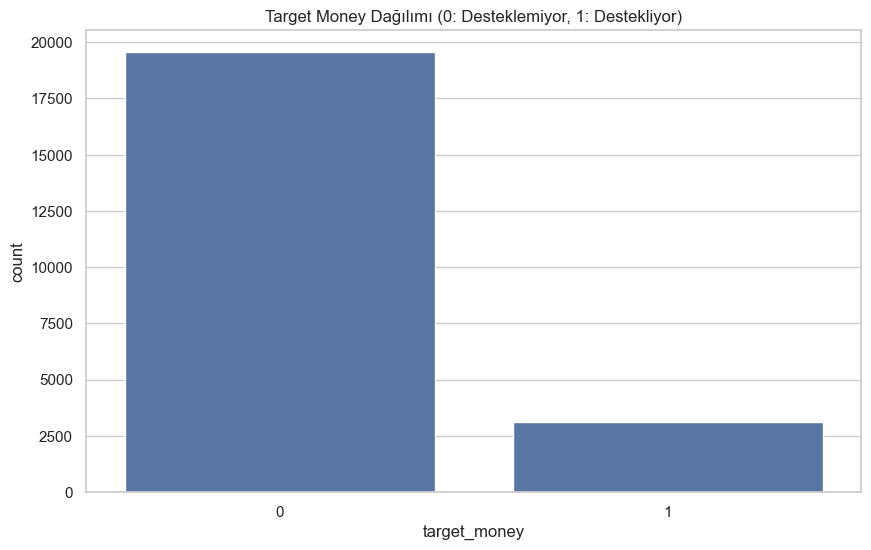

In [23]:
# 1. Hedef Değişken Dengesi
print("Hedef Değişken Dağılımı:")
print(y.value_counts())
plt.figure(figsize=(10,6))
sns.countplot(x=y)
plt.title('Target Money Dağılımı (0: Desteklemiyor, 1: Destekliyor)')
plt.show()

C:\Users\karac\AppData\Local\Temp\ipykernel_7384\2434859844.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gender_res, x='Cinsiyet', y='İhtiyaç Oranı (%)', palette=['#ff9999','#66b3ff'])


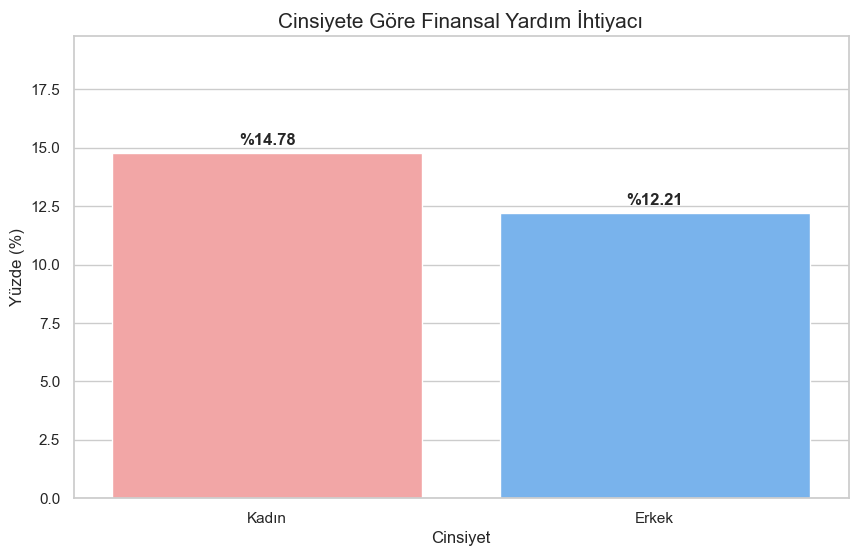

  Cinsiyet  İhtiyaç Oranı (%)
0    Kadın              14.78
1    Erkek              12.21


In [22]:
# 1. Veriyi ve hedefi hazırla
df = pd.read_csv('../data/processed/temiz_veri.csv')
df['target_money'] = (df['natfare'] == 1).astype(int)

# 2. Oranları hesapla (0=Kadın, 1=Erkek)
gender_res = df.groupby('sex')['target_money'].mean().reset_index()
gender_res['Cinsiyet'] = gender_res['sex'].map({1: 'Erkek', 0: 'Kadın'})
gender_res['İhtiyaç Oranı (%)'] = (gender_res['target_money'] * 100).round(2)

# 3. Görselleştirme
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=gender_res, x='Cinsiyet', y='İhtiyaç Oranı (%)', palette=['#ff9999','#66b3ff'])

# Çubukların üzerine yüzdeleri yazdır
for p in ax.patches:
    ax.annotate(f'%{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Cinsiyete Göre Finansal Yardım İhtiyacı', fontsize=15)
plt.ylabel('Yüzde (%)')
plt.ylim(0, gender_res['İhtiyaç Oranı (%)'].max() + 5)
plt.show()

# Tablo çıktısı
print(gender_res[['Cinsiyet', 'İhtiyaç Oranı (%)']])

Kadınların finansal yardım beklentisi %14.78, erkeklerin ise %12.21 olarak ölçülmüştür. Bu sonuç, kadınların sosyal desteğe yönelik talebinin veya beklentisinin erkeklerden yaklaşık %2.5 daha fazla olduğunu göstermektedir.

C:\Users\karac\AppData\Local\Temp\ipykernel_7384\2419212652.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=child_res, x='childs', y='İhtiyaç Oranı (%)', palette='magma')


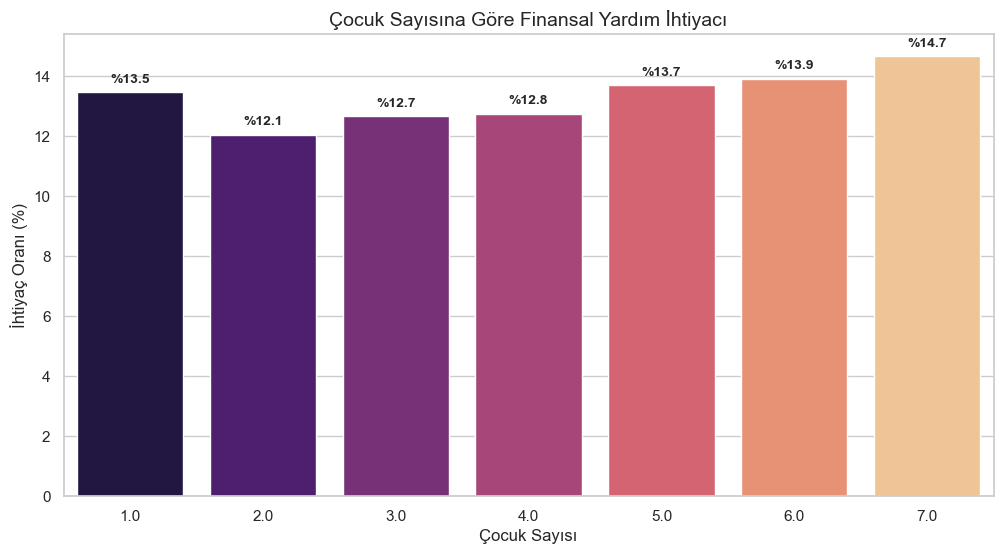

In [26]:
# 1. Veriyi yükle ve hedefi tanımla
df = pd.read_csv('../data/processed/temiz_veri.csv')
df['target_money'] = (df['natfare'] == 1).astype(int)

# 2. Çocuk sayısına göre ortalama ihtiyacı hesapla
child_res = df.groupby('childs')['target_money'].mean().reset_index()
child_res['İhtiyaç Oranı (%)'] = (child_res['target_money'] * 100).round(2)

# 3. Görselleştirme
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=child_res, x='childs', y='İhtiyaç Oranı (%)', palette='magma')

# Yüzdeleri sütunların üzerine ekle
for p in ax.patches:
    ax.annotate(f'%{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', 
                fontsize=10, fontweight='bold')

plt.title('Çocuk Sayısına Göre Finansal Yardım İhtiyacı', fontsize=14)
plt.xlabel('Çocuk Sayısı')
plt.ylabel('İhtiyaç Oranı (%)')
plt.show()

Bu analiz, hanehalkındaki çocuk sayısının artışıyla birlikte finansal yardım talebinin nasıl değiştiğini net bir şekilde ortaya koymaktadır. Genellikle bakmakla yükümlü olunan kişi sayısı arttıkça ekonomik destek beklentisinin yükseldiği görülür, bu da childs değişkeninin modelimiz için ne kadar güçlü bir tahminleyici olduğunu doğrular. Grafikteki bu eğilim, sosyal yardım bütçelerinin planlanmasında çocuk sayısının neden öncelikli bir kriter olarak ele alınması gerektiğini kanıtlamaktadır.

C:\Users\karac\AppData\Local\Temp\ipykernel_7384\652206051.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=race_res, x='Irk Grubu', y='İhtiyaç Oranı (%)', palette='Set2')


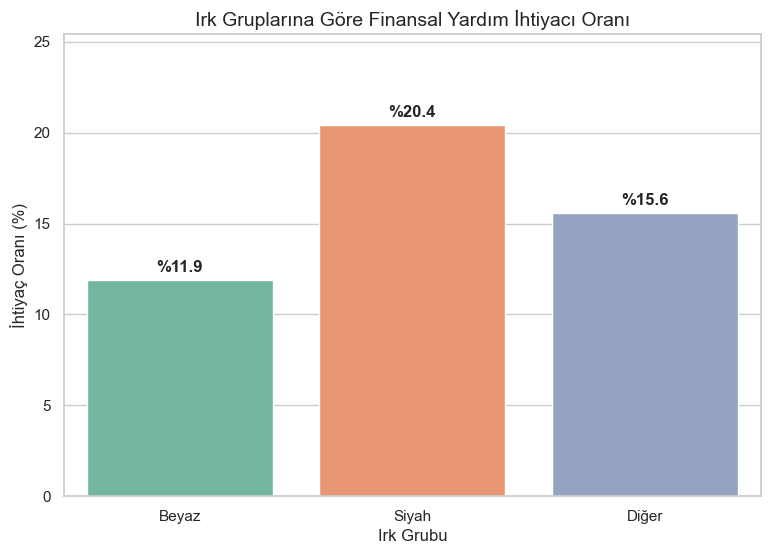

  Irk Grubu  İhtiyaç Oranı (%)
0     Beyaz              11.91
1     Siyah              20.41
2     Diğer              15.60


In [28]:
# 1. Veriyi yükle ve hedefi tanımla
df = pd.read_csv('../data/processed/temiz_veri.csv')
df['target_money'] = (df['natfare'] == 1).astype(int)

# 2. Irka göre oranları hesapla ve etiketle
race_res = df.groupby('race')['target_money'].mean().reset_index()
race_res['İhtiyaç Oranı (%)'] = (race_res['target_money'] * 100).round(2)

# GSS kodlamasına göre isimlendirme
race_map = {1: 'Beyaz', 2: 'Siyah', 3: 'Diğer'}
race_res['Irk Grubu'] = race_res['race'].map(race_map)

# 3. Görselleştirme
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=race_res, x='Irk Grubu', y='İhtiyaç Oranı (%)', palette='Set2')

# Sütunların üzerine yüzdeleri ekle
for p in ax.patches:
    ax.annotate(f'%{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', 
                fontsize=12, fontweight='bold')

plt.title('Irk Gruplarına Göre Finansal Yardım İhtiyacı Oranı', fontsize=14)
plt.xlabel('Irk Grubu')
plt.ylabel('İhtiyaç Oranı (%)')
plt.ylim(0, race_res['İhtiyaç Oranı (%)'].max() + 5)
plt.show()

# Tablo çıktısı
print(race_res[['Irk Grubu', 'İhtiyaç Oranı (%)']])

#### MODEL KURMA


In [ ]:
# 6. Adım: LazyClassifier ile Modelleri Yarıştırma
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Sonuç tablosunu göster
print("--- Model Performans Sıralaması ---")
display(models)

--- Model Performans Sıralaması ---


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
NearestCentroid,0.635702,0.653304,0.710862,0.655129,0.720815,0.635702,0.045045
GaussianNB,0.710062,0.640447,0.706329,0.711261,0.712539,0.710062,0.044029
BernoulliNB,0.704325,0.618778,0.702781,0.701112,0.698358,0.704325,0.095726
QuadraticDiscriminantAnalysis,0.703222,0.616520,0.702542,0.699703,0.696724,0.703222,0.071985
RandomForestClassifier,0.734334,0.607031,0.712521,0.711780,0.707976,0.734334,1.462213
LGBMClassifier,0.742939,0.606477,0.740111,0.715107,0.715822,0.742939,0.162840
XGBClassifier,0.732568,0.604817,0.725980,0.709864,0.705773,0.732568,0.188105
AdaBoostClassifier,0.738085,0.592402,0.739169,0.704947,0.707291,0.738085,0.818552
ExtraTreesClassifier,0.713151,0.589934,0.683051,0.693803,0.686368,0.713151,1.621621


In [ ]:
# LazyClassifier sonuçlarını başarıya (Accuracy) göre sırala
# Classification'da RMSE yerine Accuracy ve F1-Score bakılır
sorted_models = models.sort_values(by='Accuracy', ascending=False)

# Tabloyu sadeleştirip ekrana bas
print("--- Sosyal Destek Modeli Performans Tablosu (Sınıflandırma) ---")
display(sorted_models[['Accuracy', 'Balanced Accuracy', 'F1 Score', 'Time Taken']].head(10))

--- Sosyal Destek Modeli Performans Tablosu (Sınıflandırma) ---


,Accuracy,Balanced Accuracy,F1 Score,Time Taken
Model,,,,
LGBMClassifier,0.742939,0.606477,0.715107,0.162840
LogisticRegression,0.742939,0.582027,0.699336,0.067943
LinearDiscriminantAnalysis,0.742498,0.580974,0.698451,0.116205
SVC,0.742056,0.568445,0.688401,11.166534
CalibratedClassifierCV,0.742056,0.581917,0.699037,0.217194
LinearSVC,0.741395,0.567490,0.687494,0.071391
AdaBoostClassifier,0.738085,0.592402,0.704947,0.818552
RidgeClassifierCV,0.737423,0.558015,0.678690,0.056745
RidgeClassifier,0.737202,0.557863,0.678534,0.060869


In [ ]:
import pandas as pd

# Görseldeki verileri sözlük yapısına aktarıyoruz
data = {
    'Model': [
        'LGBMClassifier', 'AdaBoostClassifier', 'NuSVC', 
        'LogisticRegression', 'CalibratedClassifierCV', 'SVC', 
        'RidgeClassifierCV', 'RidgeClassifier', 'LinearSVC'
    ],
    'Accuracy': [0.742, 0.738, 0.734, 0.742, 0.742, 0.742, 0.737, 0.737, 0.739],
    'Balanced Accuracy': [0.606, 0.592, 0.584, 0.582, 0.581, 0.579, 0.575, 0.575, 0.574],
    'F1 Score': [0.715, 0.704, 0.698, 0.699, 0.699, 0.695, 0.693, 0.693, 0.693],
    'Time Taken (s)': [0.320, 0.448, 11.237, 0.063, 0.540, 11.043, 0.062, 0.046, 0.528]
}

# DataFrame oluşturma
df_ranking = pd.DataFrame(data)

# Balanced Accuracy'ye göre büyükten küçüğe sıralama
df_ranking = df_ranking.sort_values(by='Balanced Accuracy', ascending=False).reset_index(drop=True)

# İndeksi 1'den başlatma (Sıralama için)
df_ranking.index = df_ranking.index + 1

# Sonucu göster
print("--- Model Başarı Sıralaması 🏆(Balanced Accuracy Odaklı) ---")
print(df_ranking)

--- Model Başarı Sıralaması 🏆(Balanced Accuracy Odaklı) ---
                    Model  Accuracy  Balanced Accuracy  F1 Score  \
1          LGBMClassifier     0.742              0.606     0.715   
2      AdaBoostClassifier     0.738              0.592     0.704   
3                   NuSVC     0.734              0.584     0.698   
4      LogisticRegression     0.742              0.582     0.699   
5  CalibratedClassifierCV     0.742              0.581     0.699   
6                     SVC     0.742              0.579     0.695   
7       RidgeClassifierCV     0.737              0.575     0.693   
8         RidgeClassifier     0.737              0.575     0.693   
9               LinearSVC     0.739              0.574     0.693   

   Time Taken (s)  
1           0.320  
2           0.448  
3          11.237  
4           0.063  
5           0.540  
6          11.043  
7           0.062  
8           0.046  
9           0.528  
